# QF-EKF Analysis — Quantum Filter Pre-processed EKF
**Filtered sensor data (RQNN pre-filter) + dual-EKF**

Topics consumed (from `record_hybrid_bag.sh`):
- `/imu/data` + `/imu/data/filtered`
- `/diff_drive_controller/odom` + `/diff_drive_controller/odom/filtered`
- `/odometry/visual` + `/odometry/visual/filtered`
- `/odometry/lidar` + `/odometry/lidar/filtered`
- `/gps/fix` + `/gps/fix/filtered`
- `/odometry/local` — QF-EKF #1 output (odom frame)
- `/odometry/global` — QF-EKF #2 output (map frame)
- `/cmd_vel`

**Record with:**
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
bash /home/anish/Multi-sensor-fusion/record_hybrid_bag.sh
```

In [1]:
# ── SET BAG PATH ──────────────────────────────────────────────────────────────
BAG_PATH = '/home/rosdata/rosbags/moving_bot_live_test_20260420_223434'
PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots/qf_ekf'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

C = {
    'raw':        '#ff6b6b',
    'filtered':   '#51cf66',
    'visual_raw': '#a29bfe',
    'visual_flt': '#6c5ce7',
    'lidar_raw':  '#74b9ff',
    'lidar_flt':  '#0984e3',
    'ekf_local':  '#51cf66',
    'ekf_global': '#339af0',
    'gps':        '#ffd43b',
    'imu':        '#20c997',
    'cmd_vel':    '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def noise_std(sig, wl=None):
    if wl is None:
        wl = min(51, max(5, (len(sig)//5)*2+1))
        if wl % 2 == 0: wl += 1
    if len(sig) < wl: return np.std(sig)
    return np.std(sig - savgol_filter(sig, wl, 3))

print(f'Bag: {BAG_PATH}')
print(f'Exists: {Path(BAG_PATH).exists()}')

/home/anish/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Bag: /home/rosdata/rosbags/moving_bot_live_test_20260420_223434
Exists: True


## 1. Extract Data — Raw + QNN-Filtered Pairs

In [2]:
raw = {k: [] for k in [
    'imu_raw', 'imu_flt',
    'wheel_raw', 'wheel_flt',
    'visual_raw', 'visual_flt',
    'lidar_raw', 'lidar_flt',
    'ekf_local', 'ekf_global',
    'gps', 'cmd_vel'
]}

TOPIC_MAP = {
    '/imu/data':                              'imu_raw',
    '/imu/data/filtered':                     'imu_flt',
    '/diff_drive_controller/odom':            'wheel_raw',
    '/diff_drive_controller/odom/filtered':   'wheel_flt',
    '/odometry/visual':                       'visual_raw',
    '/odometry/visual/filtered':              'visual_flt',
    '/odometry/lidar':                        'lidar_raw',
    '/odometry/lidar/filtered':               'lidar_flt',
    '/odometry/local':                        'ekf_local',
    '/odometry/global':                       'ekf_global',
    '/gps/fix':                               'gps',
    '/cmd_vel':                               'cmd_vel',
}

with AnyReader([Path(BAG_PATH)], default_typestore=typestore) as reader:
    print('Topics:', list(reader.topics.keys()))
    for connection, timestamp, rawdata in reader.messages():
        key = TOPIC_MAP.get(connection.topic)
        if key is None: continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        t = timestamp * 1e-9

        if key in ('imu_raw', 'imu_flt'):
            raw[key].append({'t': t,
                'ax': msg.linear_acceleration.x, 'ay': msg.linear_acceleration.y,
                'az': msg.linear_acceleration.z,
                'gx': msg.angular_velocity.x,
                'gy': msg.angular_velocity.y,
                'gz': msg.angular_velocity.z,
                'yaw': quat_to_yaw(msg.orientation),
            })
        elif key in ('wheel_raw','wheel_flt','visual_raw','visual_flt',
                     'lidar_raw','lidar_flt','ekf_local','ekf_global'):
            raw[key].append({'t': t,
                'x': msg.pose.pose.position.x,
                'y': msg.pose.pose.position.y,
                'yaw': quat_to_yaw(msg.pose.pose.orientation),
                'vx': msg.twist.twist.linear.x,
                'wz': msg.twist.twist.angular.z,
                'cov_xx': msg.pose.covariance[0],
                'cov_yy': msg.pose.covariance[7],
            })
        elif key == 'gps':
            raw[key].append({'t': t, 'lat': msg.latitude, 'lon': msg.longitude})
        elif key == 'cmd_vel':
            raw[key].append({'t': t, 'vx': msg.linear.x, 'wz': msg.angular.z})

dfs = {}
t0 = min(raw[k][0]['t'] for k in raw if raw[k])
for k, rows in raw.items():
    if rows:
        df = pd.DataFrame(rows)
        df['t'] -= t0
        dfs[k] = df

print(f'\n{"Source":>15}  {"Msgs":>6}  {"Duration":>9}  {"Rate":>8}')
print('─' * 48)
for k, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz  = len(df) / dur if dur > 0 else 0
    print(f'{k:>15}  {len(df):6d}  {dur:8.1f}s  {hz:7.1f} Hz')

Topics: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/diff_drive_controller/odom/filtered', '/gps/fix', '/gps/fix/filtered', '/imu/data', '/imu/data/filtered', '/joint_states', '/odometry/global', '/odometry/lidar', '/odometry/lidar/filtered', '/odometry/local', '/odometry/visual', '/odometry/visual/filtered', '/tf', '/tf_static']

         Source    Msgs   Duration      Rate
────────────────────────────────────────────────
        imu_raw   10535     136.9s     76.9 Hz
        imu_flt   10529     136.9s     76.9 Hz
      wheel_raw    2634     136.9s     19.2 Hz
      wheel_flt    2633     136.9s     19.2 Hz
     visual_raw      84     131.5s      0.6 Hz
     visual_flt      84     131.5s      0.6 Hz
      lidar_raw     263     136.2s      1.9 Hz
      lidar_flt     263     136.2s      1.9 Hz
      ekf_local    2634     136.9s     19.2 Hz
     ekf_global    2623     137.0s     19.1 Hz
            gps     527     136.8s      3.9 Hz
        cmd_vel    2879     108.1s     26.6 H

## 2. QNN Filter Effectiveness — IMU
Raw vs filtered for each IMU channel. Quantify: noise reduction, zero-lag preservation.

   Channel       Raw σ       Flt σ   Reduction%   SNR gain (dB)
──────────────────────────────────────────────────────────────
     Accel     0.24580     0.07049        71.3%           10.85 dB
     Accel     0.18980     0.08303        56.3%            7.18 dB
     Accel     0.04423     0.00169        96.2%           28.35 dB
      Gyro     0.00874     0.00000       100.0%           79.77 dB
      Gyro     0.00886     0.00000       100.0%           69.56 dB
      Gyro     0.01122     0.00965        14.0%            1.31 dB


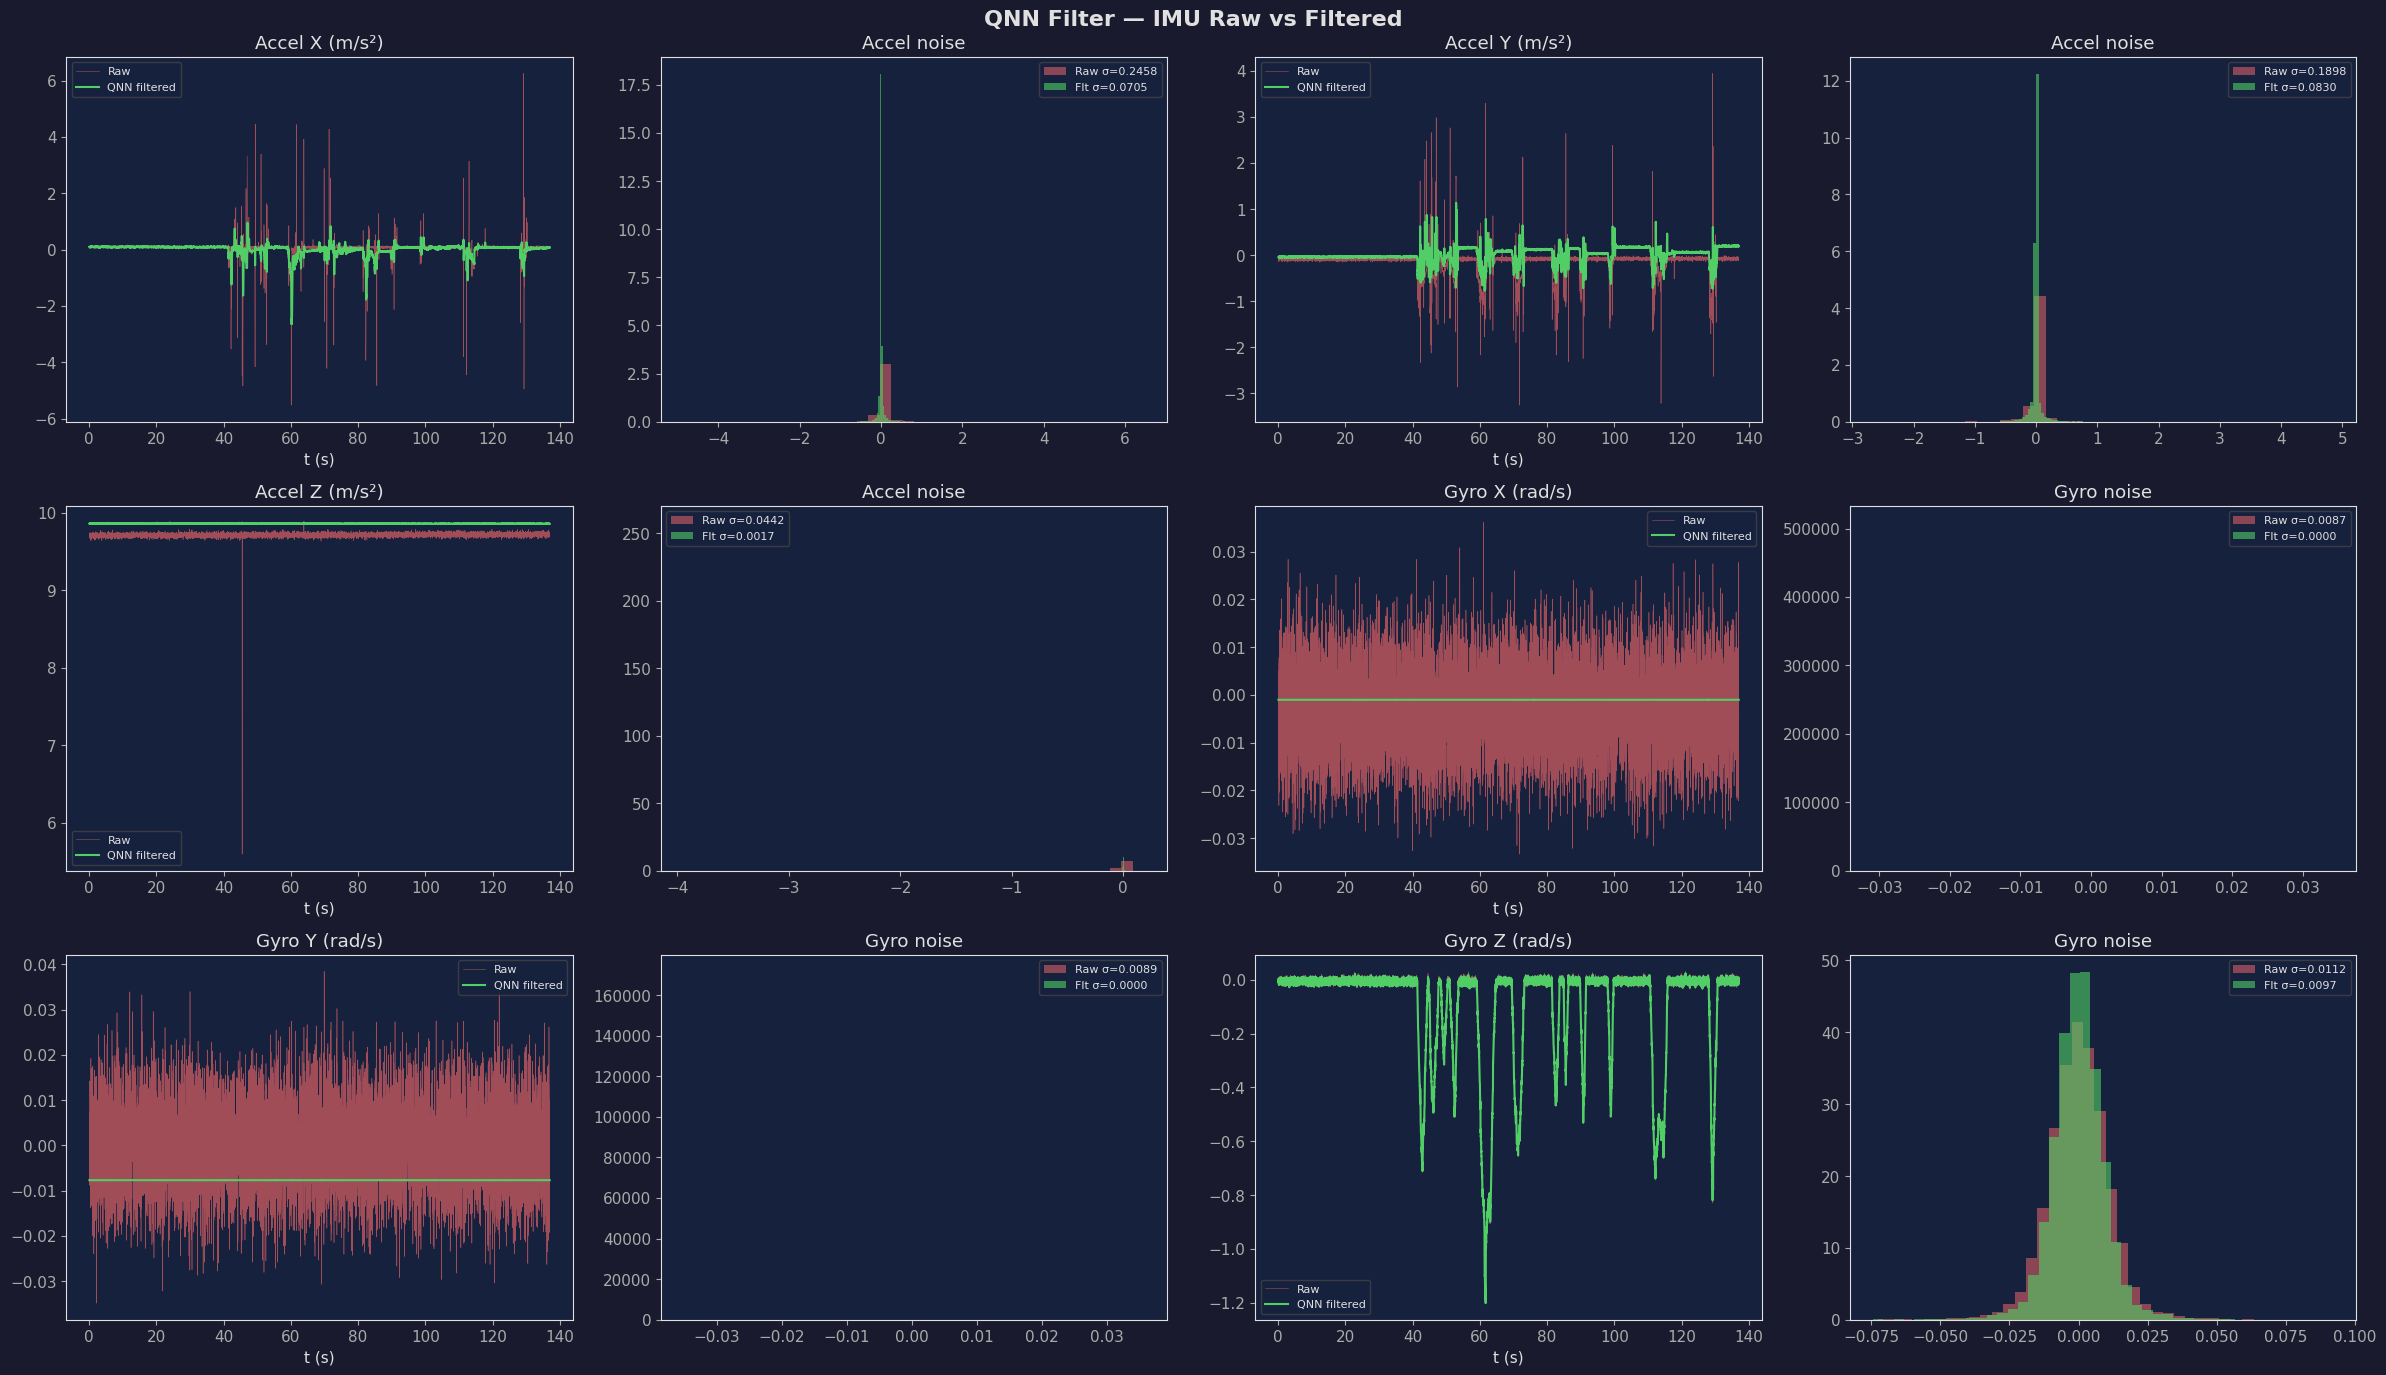

In [3]:
if 'imu_raw' not in dfs or 'imu_flt' not in dfs:
    print('Need /imu/data and /imu/data/filtered')
else:
    imu_r = dfs['imu_raw']
    imu_f = dfs['imu_flt']
    channels = [
        ('ax','Accel X (m/s²)'), ('ay','Accel Y (m/s²)'), ('az','Accel Z (m/s²)'),
        ('gx','Gyro X (rad/s)'), ('gy','Gyro Y (rad/s)'), ('gz','Gyro Z (rad/s)'),
    ]

    fig, axes = plt.subplots(3, 4, figsize=(24, 14))
    fig.suptitle('QNN Filter — IMU Raw vs Filtered', fontsize=16, fontweight='bold')

    print(f'{"Channel":>10}  {"Raw σ":>10}  {"Flt σ":>10}  {"Reduction%":>11}  {"SNR gain (dB)":>14}')
    print('─' * 62)

    for i, (col, label) in enumerate(channels):
        row, col_i = i // 2, (i % 2) * 2

        tr = npc(imu_r, 't'); dr = npc(imu_r, col); mr = mask_finite(tr, dr)
        tf = npc(imu_f, 't'); df_ = npc(imu_f, col); mf = mask_finite(tf, df_)

        # Timeseries — overlay raw + filtered
        axes[row, col_i].plot(tr[mr], dr[mr], color=C['raw'], lw=0.4, alpha=0.6, label='Raw')
        axes[row, col_i].plot(tf[mf], df_[mf], color=C['filtered'], lw=1.5, label='QNN filtered')
        axes[row, col_i].set_title(label); axes[row, col_i].legend(fontsize=8)
        axes[row, col_i].set_xlabel('t (s)')

        # Noise histogram (detrended)
        std_r = noise_std(dr[mr])
        std_f = noise_std(df_[mf])
        noise_r = dr[mr] - savgol_filter(dr[mr], min(51,max(5,(mr.sum()//5)*2+1)), 3)
        noise_f = df_[mf] - savgol_filter(df_[mf], min(51,max(5,(mf.sum()//5)*2+1)), 3)
        axes[row, col_i+1].hist(noise_r, bins=40, density=True, color=C['raw'],
                                 alpha=0.5, label=f'Raw σ={std_r:.4f}')
        axes[row, col_i+1].hist(noise_f, bins=40, density=True, color=C['filtered'],
                                 alpha=0.6, label=f'Flt σ={std_f:.4f}')
        axes[row, col_i+1].set_title(f'{label.split(" ")[0]} noise')
        axes[row, col_i+1].legend(fontsize=8)

        red = (1 - std_f/std_r) * 100 if std_r > 0 else 0
        snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
        print(f'{label.split(" ")[0]:>10}  {std_r:10.5f}  {std_f:10.5f}  {red:10.1f}%  {snr:14.2f} dB')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/01_qnn_imu_filter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. QNN Filter Effectiveness — Odometry Sources

      Source   Chan      Raw σ      Flt σ    Reduc%    SNR dB
────────────────────────────────────────────────────────────
  Wheel Odom     vx    0.01813    0.01875     -3.4%     -0.29 dB
  Wheel Odom     wz    0.02537    0.02661     -4.9%     -0.41 dB
 Visual Odom     vx    1.99080    0.60565     69.6%     10.34 dB
 Visual Odom     wz    0.53545    0.03581     93.3%     23.49 dB
  LiDAR Odom     vx    0.25293    0.24730      2.2%      0.20 dB
  LiDAR Odom     wz    0.17550    0.17418      0.7%      0.07 dB


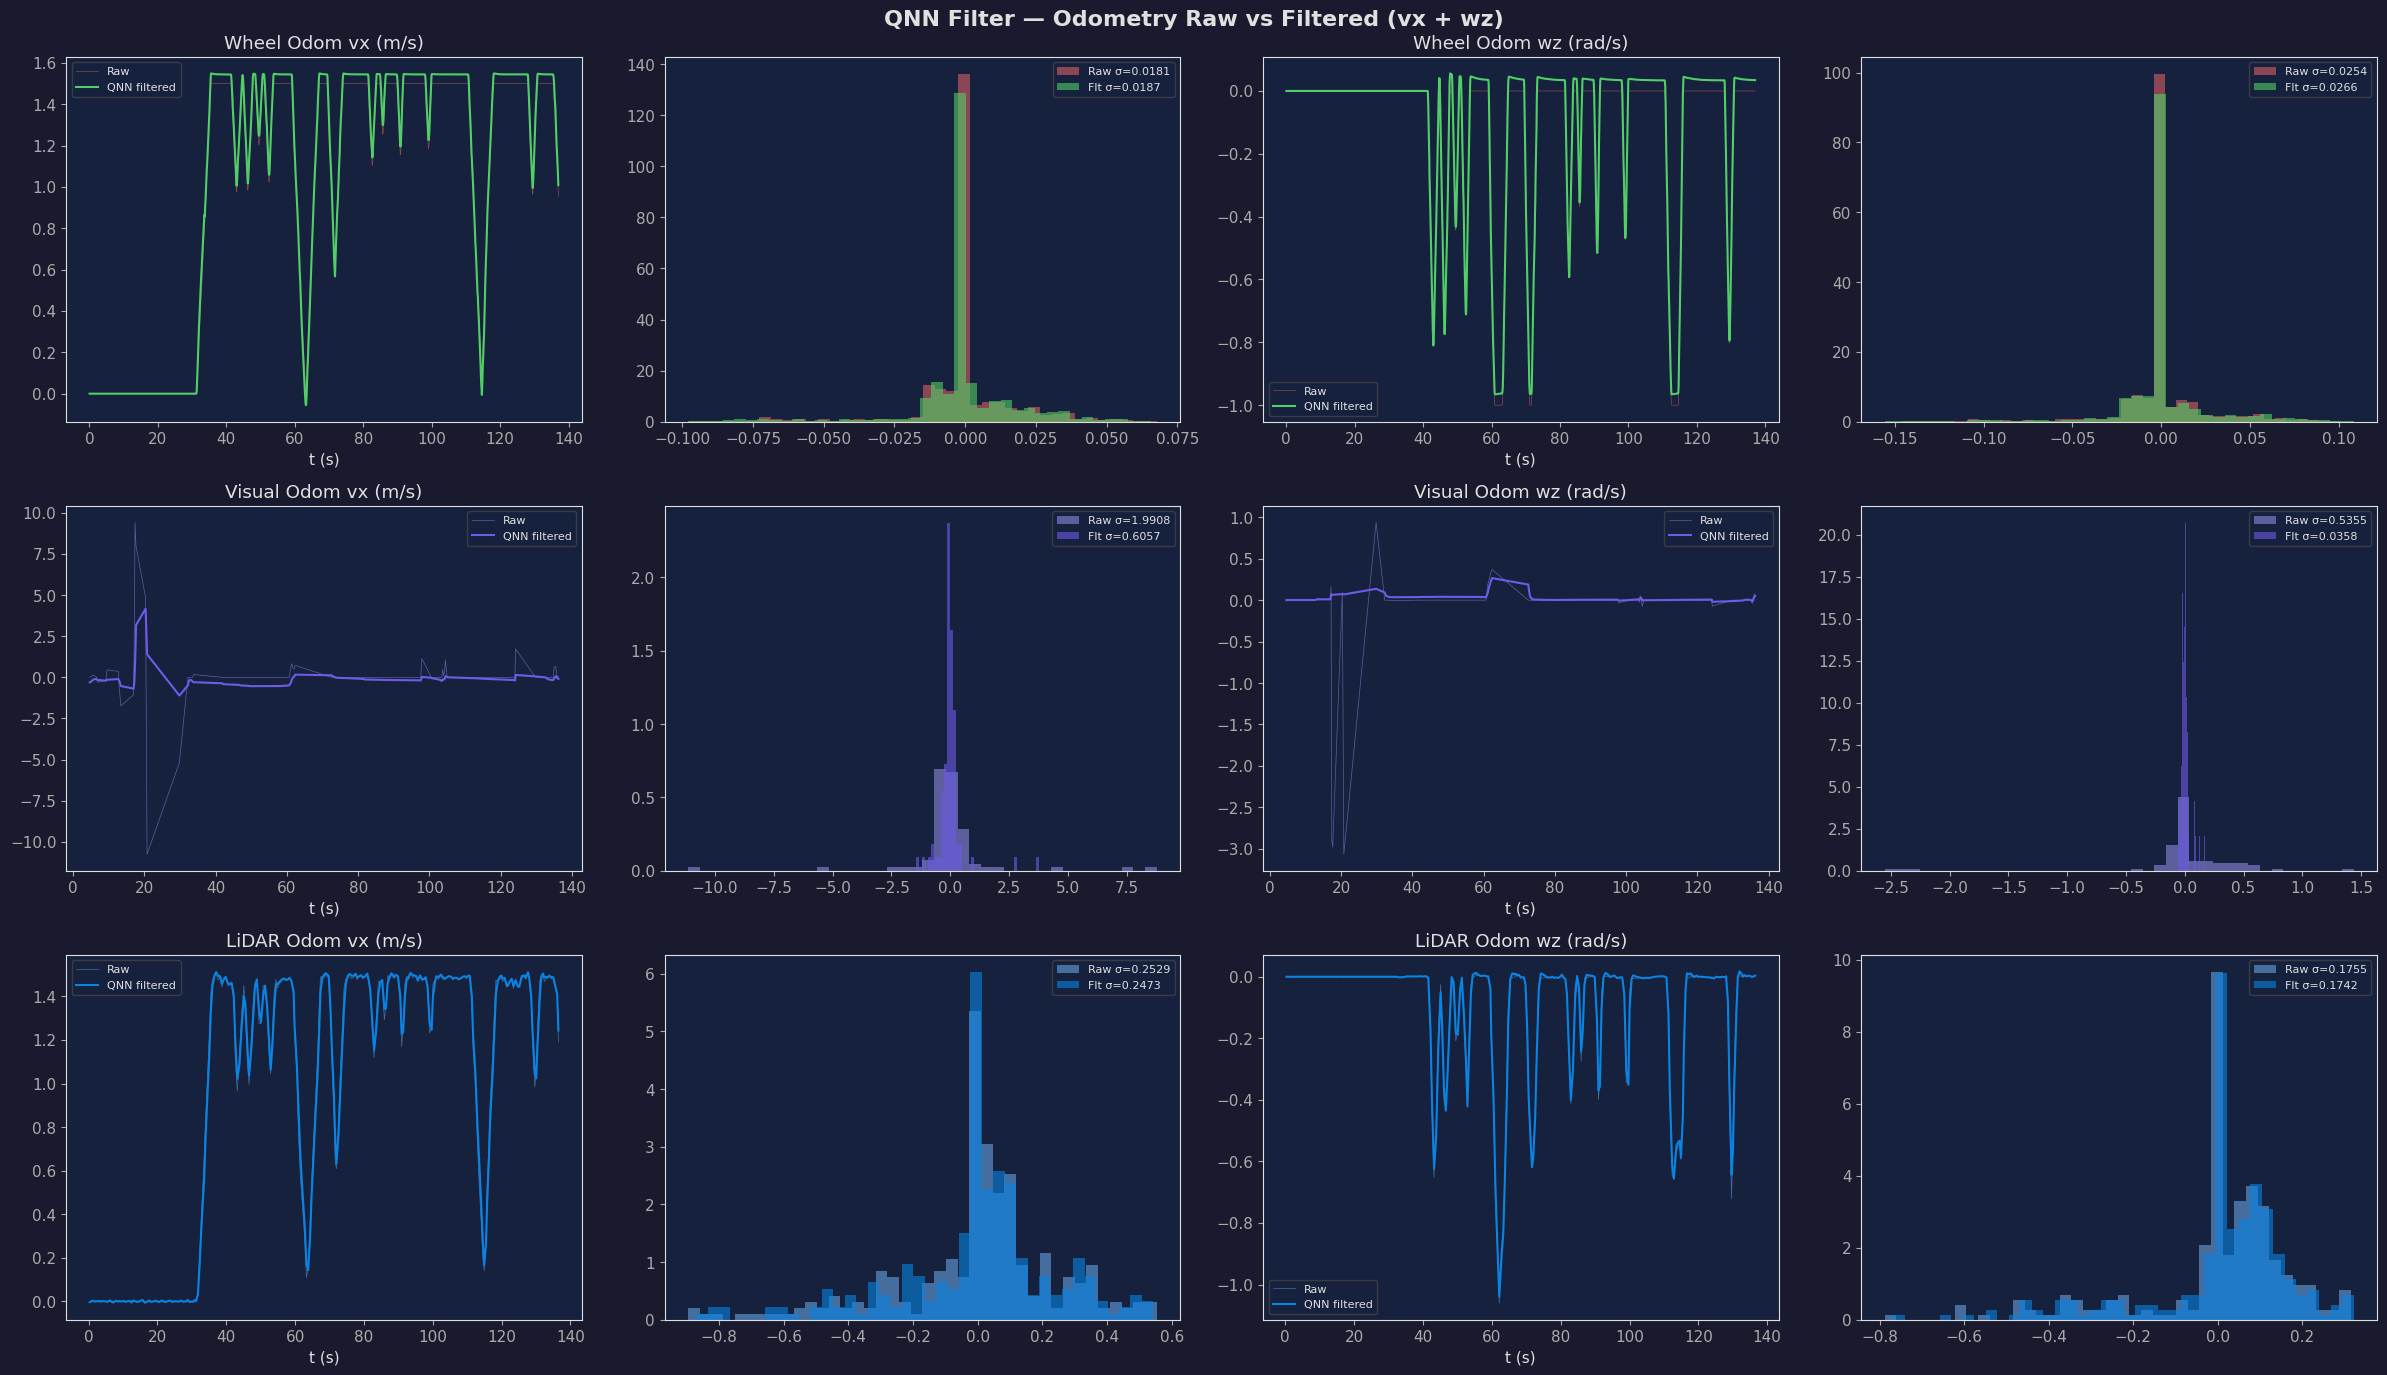

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle('QNN Filter — Odometry Raw vs Filtered (vx + wz)', fontsize=16, fontweight='bold')

pairs = [
    ('wheel_raw', 'wheel_flt', 'Wheel Odom',  C['raw'],        C['filtered']),
    ('visual_raw','visual_flt','Visual Odom',  C['visual_raw'], C['visual_flt']),
    ('lidar_raw', 'lidar_flt', 'LiDAR Odom',  C['lidar_raw'],  C['lidar_flt']),
]

print(f'{"Source":>12}  {"Chan":>5}  {"Raw σ":>9}  {"Flt σ":>9}  {"Reduc%":>8}  {"SNR dB":>8}')
print('─' * 60)

for row, (k_raw, k_flt, name, c_r, c_f) in enumerate(pairs):
    if k_raw not in dfs or k_flt not in dfs:
        print(f'{name}: data missing')
        continue

    for col_i, (col, label) in enumerate([('vx', 'vx (m/s)'), ('wz', 'wz (rad/s)')]):
        tr = npc(dfs[k_raw], 't'); dr = npc(dfs[k_raw], col); mr = mask_finite(tr, dr)
        tf = npc(dfs[k_flt], 't'); df_ = npc(dfs[k_flt], col); mf = mask_finite(tf, df_)

        # Timeseries
        axes[row, col_i*2].plot(tr[mr], dr[mr], color=c_r, lw=0.5, alpha=0.5, label='Raw')
        axes[row, col_i*2].plot(tf[mf], df_[mf], color=c_f, lw=1.5, label='QNN filtered')
        axes[row, col_i*2].set_title(f'{name} {label}')
        axes[row, col_i*2].legend(fontsize=8); axes[row, col_i*2].set_xlabel('t (s)')

        # Residual histogram
        std_r = noise_std(dr[mr])
        std_f = noise_std(df_[mf])
        wl = min(51, max(5, (mr.sum()//5)*2+1))
        if wl%2==0: wl+=1
        noise_r = dr[mr] - savgol_filter(dr[mr], wl, 3)
        wl2 = min(51, max(5, (mf.sum()//5)*2+1))
        if wl2%2==0: wl2+=1
        noise_f = df_[mf] - savgol_filter(df_[mf], wl2, 3)
        axes[row, col_i*2+1].hist(noise_r, bins=40, density=True, color=c_r,
                                   alpha=0.5, label=f'Raw σ={std_r:.4f}')
        axes[row, col_i*2+1].hist(noise_f, bins=40, density=True, color=c_f,
                                   alpha=0.6, label=f'Flt σ={std_f:.4f}')
        axes[row, col_i*2+1].legend(fontsize=8)

        red = (1 - std_f/std_r) * 100 if std_r > 0 else 0
        snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
        print(f'{name:>12}  {col:>5}  {std_r:9.5f}  {std_f:9.5f}  {red:7.1f}%  {snr:8.2f} dB')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_qnn_odom_filter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Phase Lag Check — QNN Zero-Lag Verification
Cross-correlate raw vs filtered to measure any phase delay introduced by RQNN.

        Channel    Peak lag (samples)    Peak lag (ms)
───────────────────────────────────────────────────────
     IMU Gyro Z                    -1           -13.00 ms
    IMU Accel X                    -3           -39.00 ms
       Wheel vx                     0             0.00 ms
      Visual vx                    -1         -1584.85 ms
       LiDAR vx                     0             0.00 ms
       Wheel wz                     0             0.00 ms


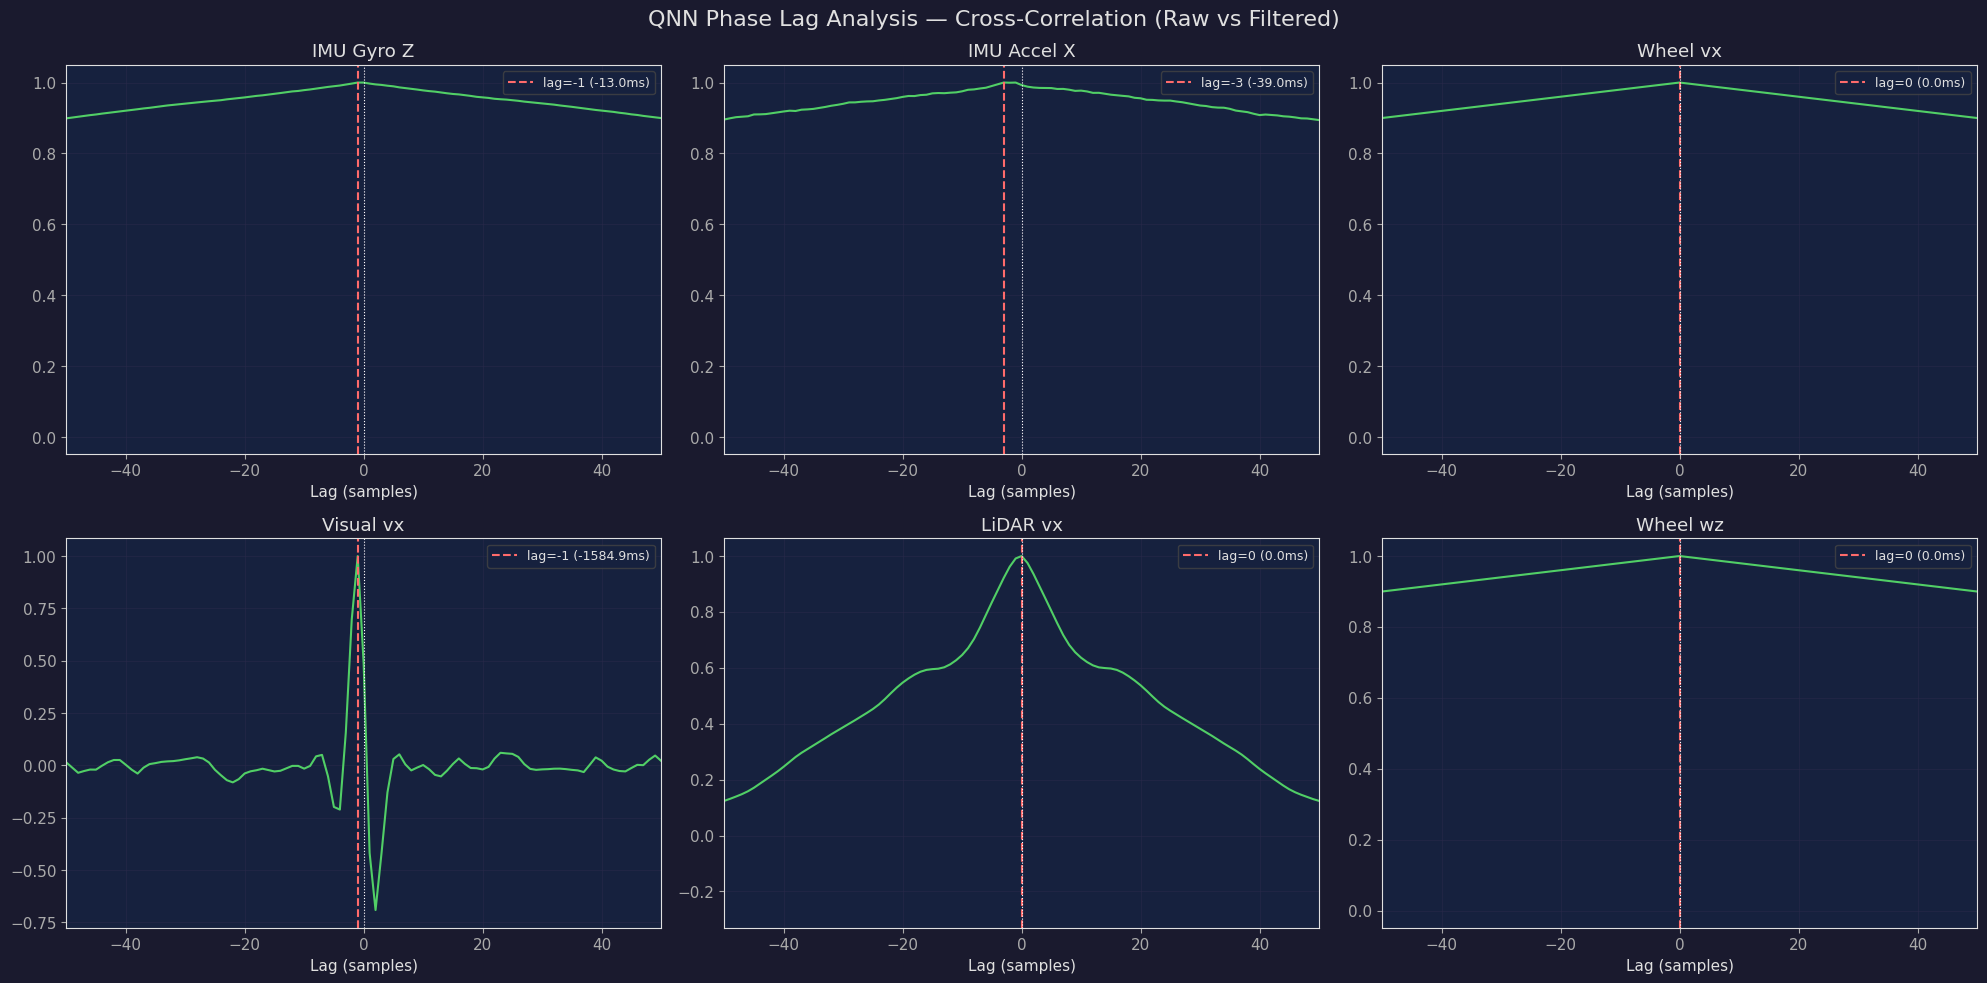

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('QNN Phase Lag Analysis — Cross-Correlation (Raw vs Filtered)', fontsize=16)

pairs_lag = [
    ('imu_raw',   'imu_flt',   'gz',  'IMU Gyro Z'),
    ('imu_raw',   'imu_flt',   'ax',  'IMU Accel X'),
    ('wheel_raw', 'wheel_flt', 'vx',  'Wheel vx'),
    ('visual_raw','visual_flt','vx',  'Visual vx'),
    ('lidar_raw', 'lidar_flt', 'vx',  'LiDAR vx'),
    ('wheel_raw', 'wheel_flt', 'wz',  'Wheel wz'),
]

print(f'{"Channel":>15}  {"Peak lag (samples)":>20}  {"Peak lag (ms)":>15}')
print('─' * 55)

for ax, (k_raw, k_flt, col, label) in zip(axes.flat, pairs_lag):
    if k_raw not in dfs or k_flt not in dfs:
        ax.set_title(f'{label}: missing'); continue

    dr = npc(dfs[k_raw], col); tr = npc(dfs[k_raw], 't')
    df_ = npc(dfs[k_flt], col); tf = npc(dfs[k_flt], 't')
    mr = mask_finite(tr, dr); mf = mask_finite(tf, df_)

    # Interpolate filtered to raw timestamps
    df_interp = np.interp(tr[mr], tf[mf], df_[mf])
    dr_z = dr[mr] - dr[mr].mean()
    df_z = df_interp - df_interp.mean()

    n = min(len(dr_z), 500)
    xcorr = np.correlate(dr_z[:n], df_z[:n], mode='full')
    lags = np.arange(-(n-1), n)
    peak_lag = lags[np.argmax(xcorr)]

    fs = 1.0 / np.mean(np.diff(tr[mr]))
    peak_ms = peak_lag / fs * 1000

    ax.plot(lags, xcorr / xcorr.max(), color=C['filtered'], lw=1.5)
    ax.axvline(peak_lag, color=C['raw'], ls='--', lw=1.5,
               label=f'lag={peak_lag} ({peak_ms:.1f}ms)')
    ax.axvline(0, color='white', ls=':', lw=0.8)
    ax.set_title(label); ax.set_xlabel('Lag (samples)')
    ax.set_xlim(-50, 50); ax.legend(fontsize=9); ax.grid(True)

    print(f'{label:>15}  {peak_lag:>20}  {peak_ms:>15.2f} ms')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_phase_lag.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. QF-EKF Trajectory

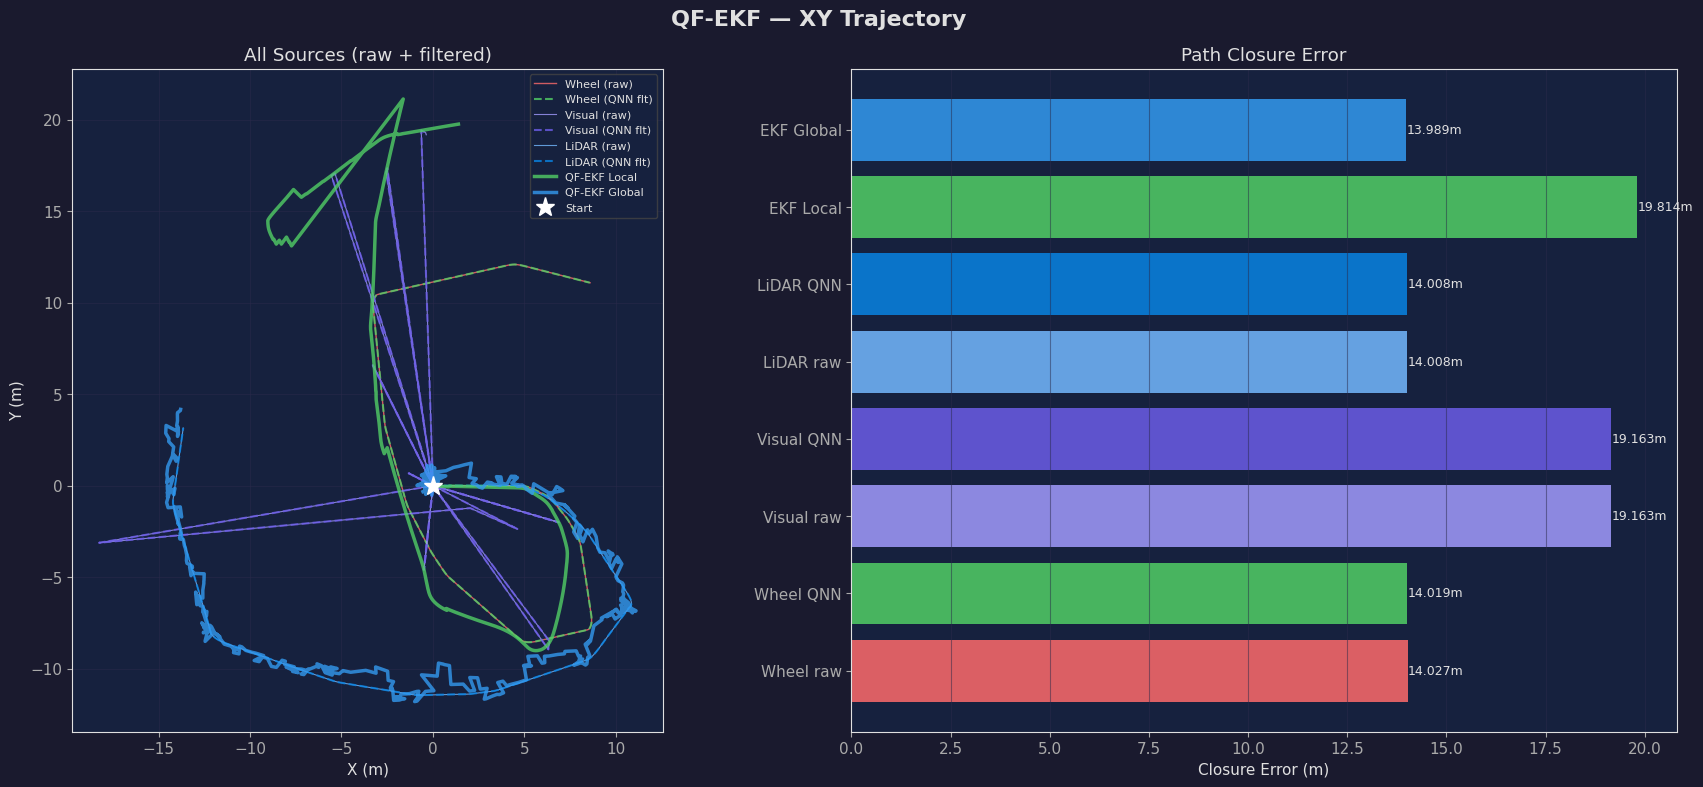

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('QF-EKF — XY Trajectory', fontsize=16, fontweight='bold')

ax = axes[0]
ax.set_title('All Sources (raw + filtered)')
for k, label, color, lw, ls in [
    ('wheel_raw',  'Wheel (raw)',      C['raw'],        1.0, '-'),
    ('wheel_flt',  'Wheel (QNN flt)',  C['filtered'],   1.5, '--'),
    ('visual_raw', 'Visual (raw)',     C['visual_raw'], 0.8, '-'),
    ('visual_flt', 'Visual (QNN flt)', C['visual_flt'], 1.5, '--'),
    ('lidar_raw',  'LiDAR (raw)',      C['lidar_raw'],  0.8, '-'),
    ('lidar_flt',  'LiDAR (QNN flt)',  C['lidar_flt'],  1.5, '--'),
    ('ekf_local',  'QF-EKF Local',     C['ekf_local'],  2.5, '-'),
    ('ekf_global', 'QF-EKF Global',    C['ekf_global'], 2.5, '-'),
]:
    if k not in dfs: continue
    x = npc(dfs[k], 'x'); y = npc(dfs[k], 'y')
    m = mask_finite(x, y)
    ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.8)

ax.plot(0, 0, 'w*', ms=14, zorder=10, label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True)

# Closure errors
ax2 = axes[1]
ax2.set_title('Path Closure Error')
names, errors, bar_c = [], [], []
color_map = {'wheel_raw': C['raw'], 'wheel_flt': C['filtered'],
             'visual_raw': C['visual_raw'], 'visual_flt': C['visual_flt'],
             'lidar_raw': C['lidar_raw'], 'lidar_flt': C['lidar_flt'],
             'ekf_local': C['ekf_local'], 'ekf_global': C['ekf_global']}
label_map = {'wheel_raw': 'Wheel raw', 'wheel_flt': 'Wheel QNN',
             'visual_raw': 'Visual raw', 'visual_flt': 'Visual QNN',
             'lidar_raw': 'LiDAR raw', 'lidar_flt': 'LiDAR QNN',
             'ekf_local': 'EKF Local', 'ekf_global': 'EKF Global'}
for k in ['wheel_raw','wheel_flt','visual_raw','visual_flt',
           'lidar_raw','lidar_flt','ekf_local','ekf_global']:
    if k not in dfs: continue
    x = npc(dfs[k], 'x'); y = npc(dfs[k], 'y')
    m = mask_finite(x, y)
    if m.sum() > 1:
        err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
        names.append(label_map[k]); errors.append(err); bar_c.append(color_map[k])
bars = ax2.barh(names, errors, color=bar_c, alpha=0.85)
for bar, err in zip(bars, errors):
    ax2.text(err + 0.01, bar.get_y() + bar.get_height()/2,
             f'{err:.3f}m', va='center', fontsize=9)
ax2.set_xlabel('Closure Error (m)'); ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Velocity — Raw vs QNN Filtered vs EKF Fused

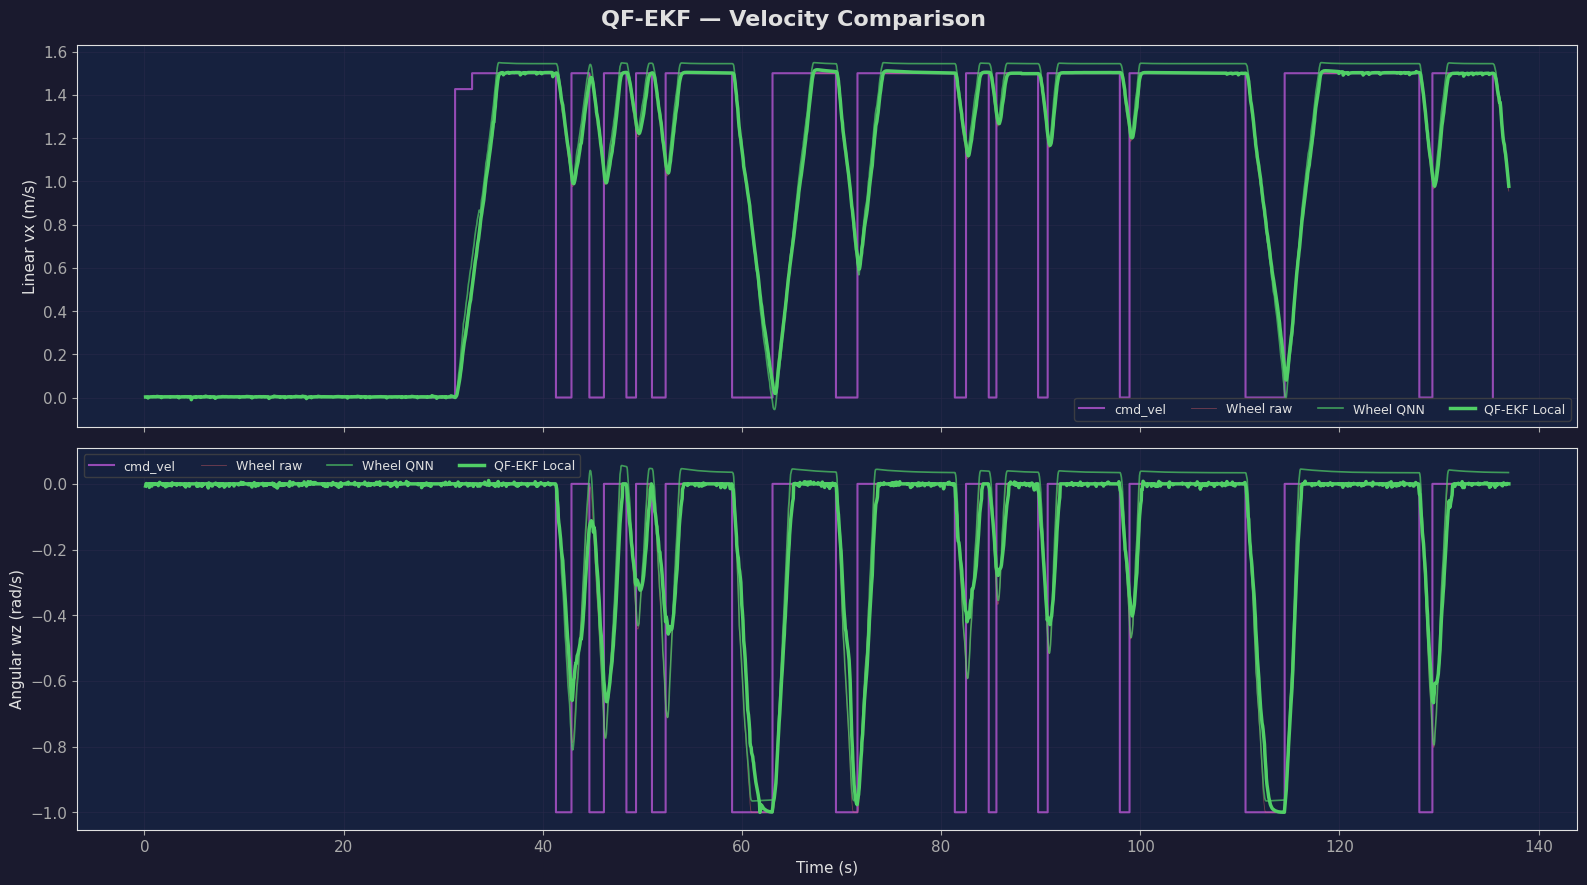

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('QF-EKF — Velocity Comparison', fontsize=16, fontweight='bold')

for col, ax, ylabel in [('vx', axes[0], 'Linear vx (m/s)'),
                          ('wz', axes[1], 'Angular wz (rad/s)')]:
    if 'cmd_vel' in dfs:
        t = npc(dfs['cmd_vel'], 't'); v = npc(dfs['cmd_vel'], col)
        m = mask_finite(t, v)
        ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, where='post',
                alpha=0.7, label='cmd_vel')
    for k, label, color, lw, alpha in [
        ('wheel_raw', 'Wheel raw',    C['raw'],       0.6, 0.4),
        ('wheel_flt', 'Wheel QNN',    C['filtered'],  1.2, 0.7),
        ('ekf_local', 'QF-EKF Local', C['ekf_local'], 2.5, 1.0),
    ]:
        if k not in dfs: continue
        t = npc(dfs[k], 't'); v = npc(dfs[k], col)
        m = mask_finite(t, v)
        ax.plot(t[m], v[m], color=color, lw=lw, alpha=alpha, label=label)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9, ncol=4); ax.grid(True)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Drift Analysis — QF-EKF Local vs Global

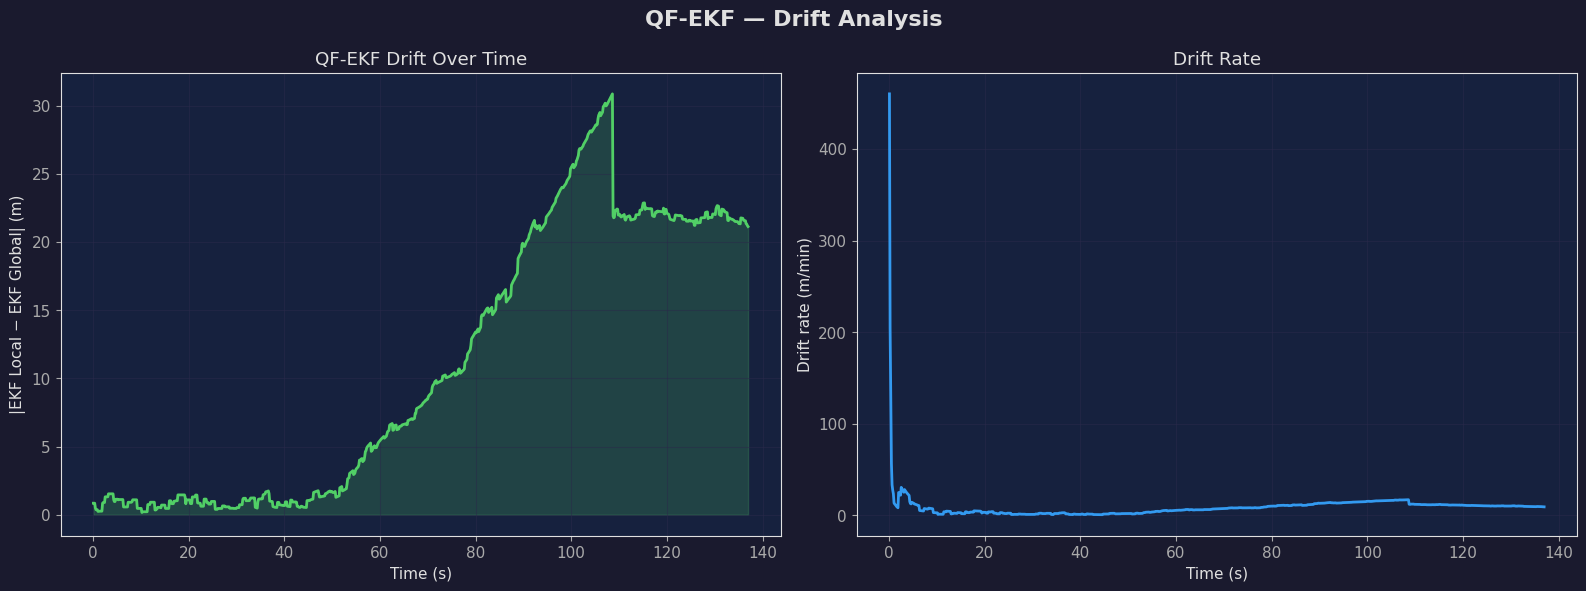


QF-EKF Drift Summary:
  Duration         : 136.9 s
  Final drift      : 21.1303 m
  Max drift        : 30.8620 m
  Mean drift rate  : 9.2633 m/min


In [8]:
if 'ekf_local' not in dfs or 'ekf_global' not in dfs:
    print('Need both /odometry/local and /odometry/global')
else:
    tl = npc(dfs['ekf_local'],'t');  xl = npc(dfs['ekf_local'],'x');  yl = npc(dfs['ekf_local'],'y')
    tg = npc(dfs['ekf_global'],'t'); xg = npc(dfs['ekf_global'],'x'); yg = npc(dfs['ekf_global'],'y')
    ml = mask_finite(tl,xl,yl); mg = mask_finite(tg,xg,yg)

    t_c = np.linspace(max(tl[ml][0],tg[mg][0]), min(tl[ml][-1],tg[mg][-1]), 1000)
    lx = np.interp(t_c, tl[ml], xl[ml]-xl[ml][0])
    ly = np.interp(t_c, tl[ml], yl[ml]-yl[ml][0])
    gx = np.interp(t_c, tg[mg], xg[mg]-xg[mg][0])
    gy = np.interp(t_c, tg[mg], yg[mg]-yg[mg][0])
    drift = np.sqrt((lx-gx)**2 + (ly-gy)**2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('QF-EKF — Drift Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(t_c, drift, color=C['filtered'], lw=2)
    axes[0].fill_between(t_c, 0, drift, color=C['filtered'], alpha=0.2)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('|EKF Local − EKF Global| (m)')
    axes[0].set_title('QF-EKF Drift Over Time'); axes[0].grid(True)

    axes[1].plot(t_c, drift/(t_c+1e-6)*60, color=C['ekf_global'], lw=2)
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Drift rate (m/min)')
    axes[1].set_title('Drift Rate'); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/06_drift.png', dpi=150, bbox_inches='tight')
    plt.show()

    dur = t_c[-1] - t_c[0]
    print('\nQF-EKF Drift Summary:')
    print(f'  Duration         : {dur:.1f} s')
    print(f'  Final drift      : {drift[-1]:.4f} m')
    print(f'  Max drift        : {drift.max():.4f} m')
    print(f'  Mean drift rate  : {drift[-1]/dur*60:.4f} m/min')

## 8. GPS Innovation — QF-EKF

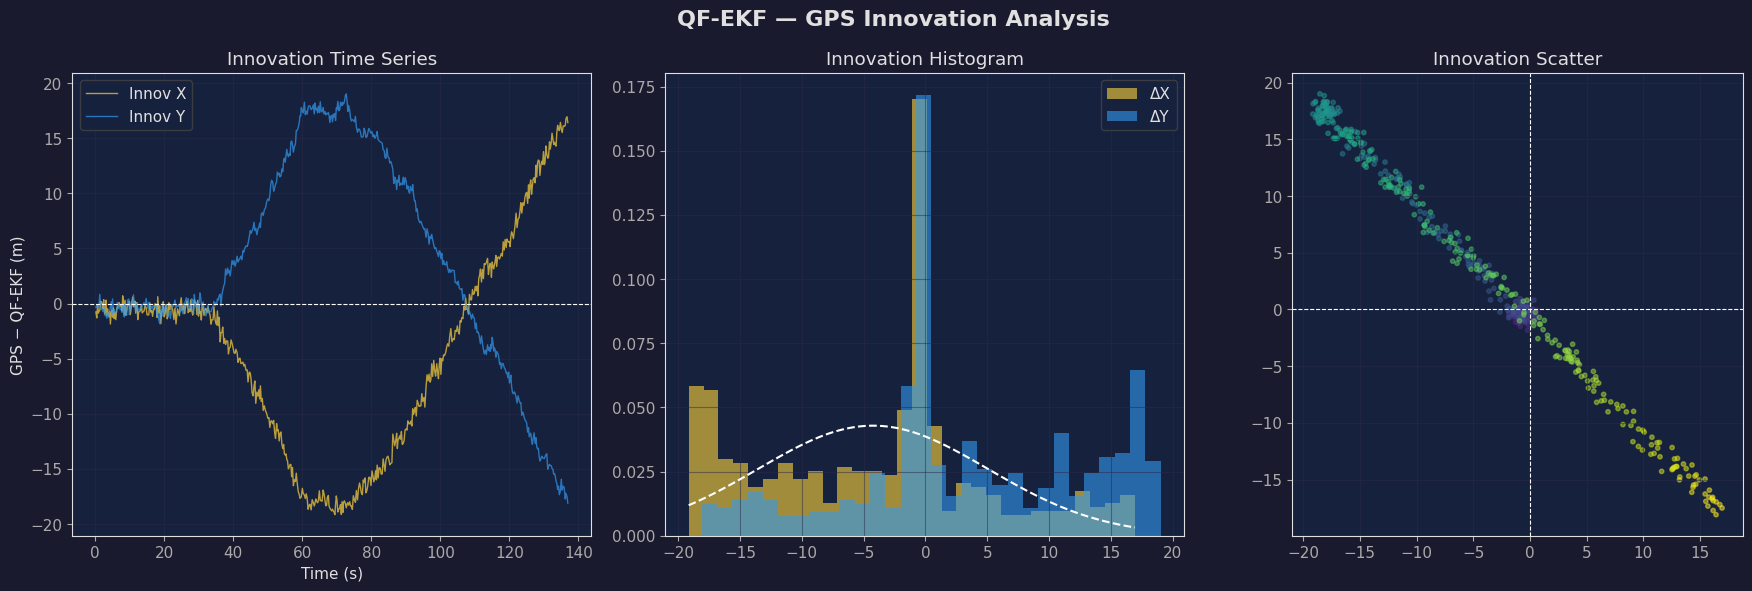


QF-EKF GPS Innovation:
  ΔX  mean=-4.2421  std=9.3040 m
  ΔY  mean=3.3931  std=9.3793 m
  2D RMSE = 14.2844 m
  Normality X: p=0.0000
  Normality Y: p=0.0000


In [9]:
if 'gps' not in dfs or 'ekf_global' not in dfs:
    print('Need /gps/fix and /odometry/global')
else:
    gps = dfs['gps']; ekf = dfs['ekf_global']
    lat = npc(gps,'lat'); lon = npc(gps,'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))
    tg = npc(gps,'t'); te = npc(ekf,'t')
    xe = npc(ekf,'x'); ye = npc(ekf,'y')
    me = mask_finite(te, xe, ye)
    lat_m += xe[me][0] - lat_m[0]
    lon_m += ye[me][0] - lon_m[0]
    mg = mask_finite(tg, lat_m, lon_m)
    innov_x = lat_m[mg] - np.interp(tg[mg], te[me], xe[me])
    innov_y = lon_m[mg] - np.interp(tg[mg], te[me], ye[me])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('QF-EKF — GPS Innovation Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(tg[mg], innov_x, color=C['gps'], lw=1, label='Innov X', alpha=0.7)
    axes[0].plot(tg[mg], innov_y, color=C['ekf_global'], lw=1, label='Innov Y', alpha=0.7)
    axes[0].axhline(0, color='white', ls='--', lw=0.8)
    axes[0].set_title('Innovation Time Series')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('GPS − QF-EKF (m)')
    axes[0].legend(); axes[0].grid(True)

    axes[1].hist(innov_x, bins=30, color=C['gps'], alpha=0.6, density=True, label='ΔX')
    axes[1].hist(innov_y, bins=30, color=C['ekf_global'], alpha=0.6, density=True, label='ΔY')
    xr = np.linspace(innov_x.min(), innov_x.max(), 100)
    axes[1].plot(xr, stats.norm.pdf(xr, innov_x.mean(), innov_x.std()), 'w--', lw=1.5)
    axes[1].set_title('Innovation Histogram'); axes[1].legend(); axes[1].grid(True)

    axes[2].scatter(innov_x, innov_y, c=tg[mg], cmap='viridis', s=10, alpha=0.5)
    axes[2].axhline(0, color='white', ls='--', lw=0.8)
    axes[2].axvline(0, color='white', ls='--', lw=0.8)
    axes[2].set_title('Innovation Scatter')
    axes[2].set_aspect('equal'); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/07_innovation.png', dpi=150, bbox_inches='tight')
    plt.show()

    rmse = np.sqrt(np.mean(innov_x**2 + innov_y**2))
    print('\nQF-EKF GPS Innovation:')
    print(f'  ΔX  mean={innov_x.mean():.4f}  std={innov_x.std():.4f} m')
    print(f'  ΔY  mean={innov_y.mean():.4f}  std={innov_y.std():.4f} m')
    print(f'  2D RMSE = {rmse:.4f} m')
    print(f'  Normality X: p={stats.normaltest(innov_x).pvalue:.4f}')
    print(f'  Normality Y: p={stats.normaltest(innov_y).pvalue:.4f}')

## 9. QNN Filter Summary Statistics

In [10]:
print('=' * 72)
print('QF-EKF — QNN FILTER SUMMARY')
print('=' * 72)
print(f'{"Channel":>18}  {"Raw σ":>9}  {"Flt σ":>9}  {"Reduction":>10}  {"SNR gain":>10}')
print('─' * 65)

pairs_sum = [
    ('imu_raw','imu_flt','gz',   'IMU Gyro Z'),
    ('imu_raw','imu_flt','ax',   'IMU Accel X'),
    ('imu_raw','imu_flt','ay',   'IMU Accel Y'),
    ('wheel_raw','wheel_flt','vx','Wheel vx'),
    ('wheel_raw','wheel_flt','wz','Wheel wz'),
    ('visual_raw','visual_flt','vx','Visual vx'),
    ('visual_raw','visual_flt','wz','Visual wz'),
    ('lidar_raw','lidar_flt','vx','LiDAR vx'),
    ('lidar_raw','lidar_flt','wz','LiDAR wz'),
]
for kr, kf, col, label in pairs_sum:
    if kr not in dfs or kf not in dfs: continue
    dr = npc(dfs[kr], col); dr = dr[np.isfinite(dr)]
    df_ = npc(dfs[kf], col); df_ = df_[np.isfinite(df_)]
    std_r = noise_std(dr)
    std_f = noise_std(df_)
    red = (1 - std_f/std_r) * 100 if std_r > 0 else 0
    snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
    print(f'{label:>18}  {std_r:9.5f}  {std_f:9.5f}  {red:9.1f}%  {snr:9.2f} dB')

if 'ekf_local' in dfs and 'ekf_global' in dfs:
    tl = npc(dfs['ekf_local'],'t');  xl = npc(dfs['ekf_local'],'x');  yl = npc(dfs['ekf_local'],'y')
    tg = npc(dfs['ekf_global'],'t'); xg = npc(dfs['ekf_global'],'x'); yg = npc(dfs['ekf_global'],'y')
    ml = mask_finite(tl,xl,yl); mg = mask_finite(tg,xg,yg)
    t_c = np.linspace(max(tl[ml][0],tg[mg][0]), min(tl[ml][-1],tg[mg][-1]), 500)
    drift = np.sqrt((np.interp(t_c,tl[ml],xl[ml]-xl[ml][0])-np.interp(t_c,tg[mg],xg[mg]-xg[mg][0]))**2 +
                    (np.interp(t_c,tl[ml],yl[ml]-yl[ml][0])-np.interp(t_c,tg[mg],yg[mg]-yg[mg][0]))**2)
    print(f'\nQF-EKF drift: {drift[-1]:.4f} m final, {drift[-1]/(t_c[-1]-t_c[0])*60:.4f} m/min')

QF-EKF — QNN FILTER SUMMARY
           Channel      Raw σ      Flt σ   Reduction    SNR gain
─────────────────────────────────────────────────────────────────
        IMU Gyro Z    0.01122    0.00965       14.0%       1.31 dB
       IMU Accel X    0.24580    0.07049       71.3%      10.85 dB
       IMU Accel Y    0.18980    0.08303       56.3%       7.18 dB
          Wheel vx    0.01813    0.01875       -3.4%      -0.29 dB
          Wheel wz    0.02537    0.02661       -4.9%      -0.41 dB
         Visual vx    1.99080    0.60565       69.6%      10.34 dB
         Visual wz    0.53545    0.03581       93.3%      23.49 dB
          LiDAR vx    0.25293    0.24730        2.2%       0.20 dB
          LiDAR wz    0.17550    0.17418        0.7%       0.07 dB

QF-EKF drift: 21.1303 m final, 9.2633 m/min
